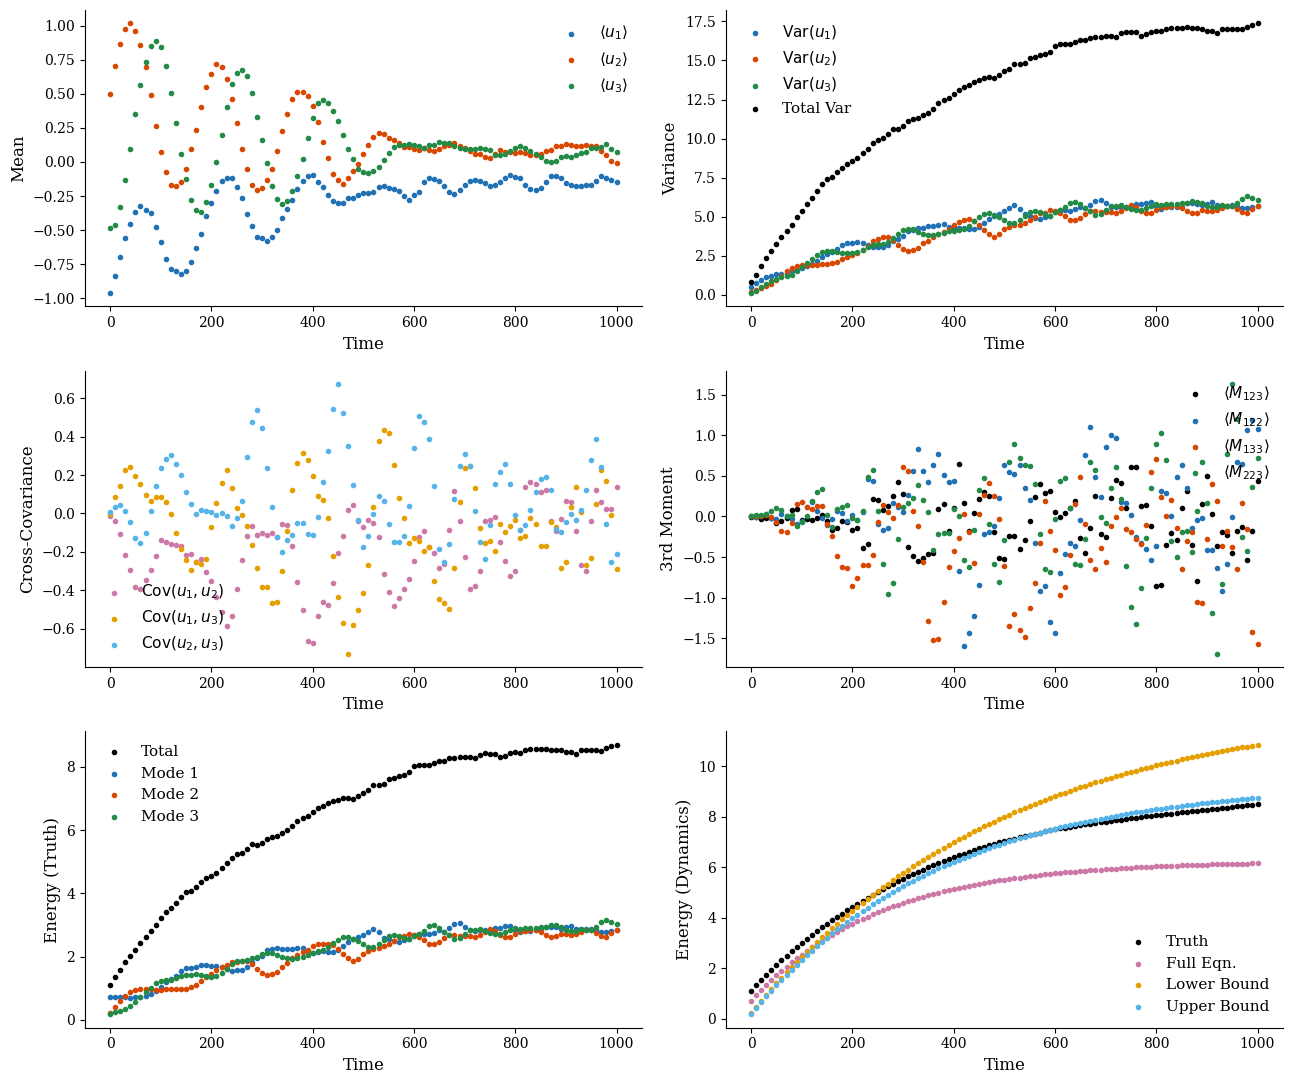

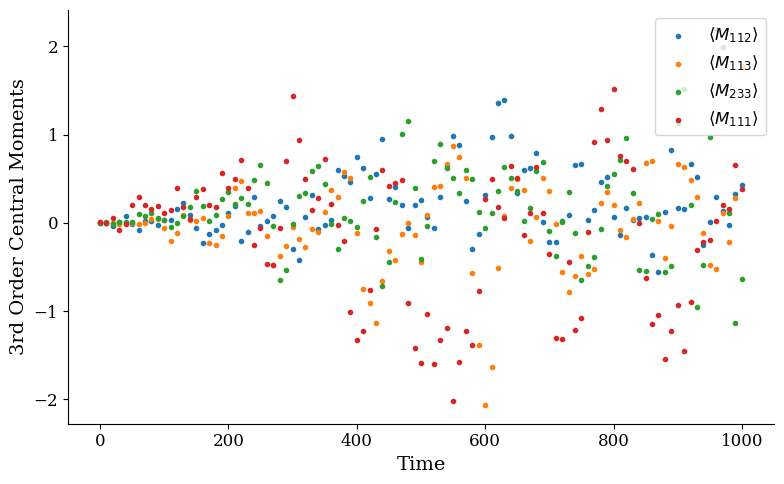

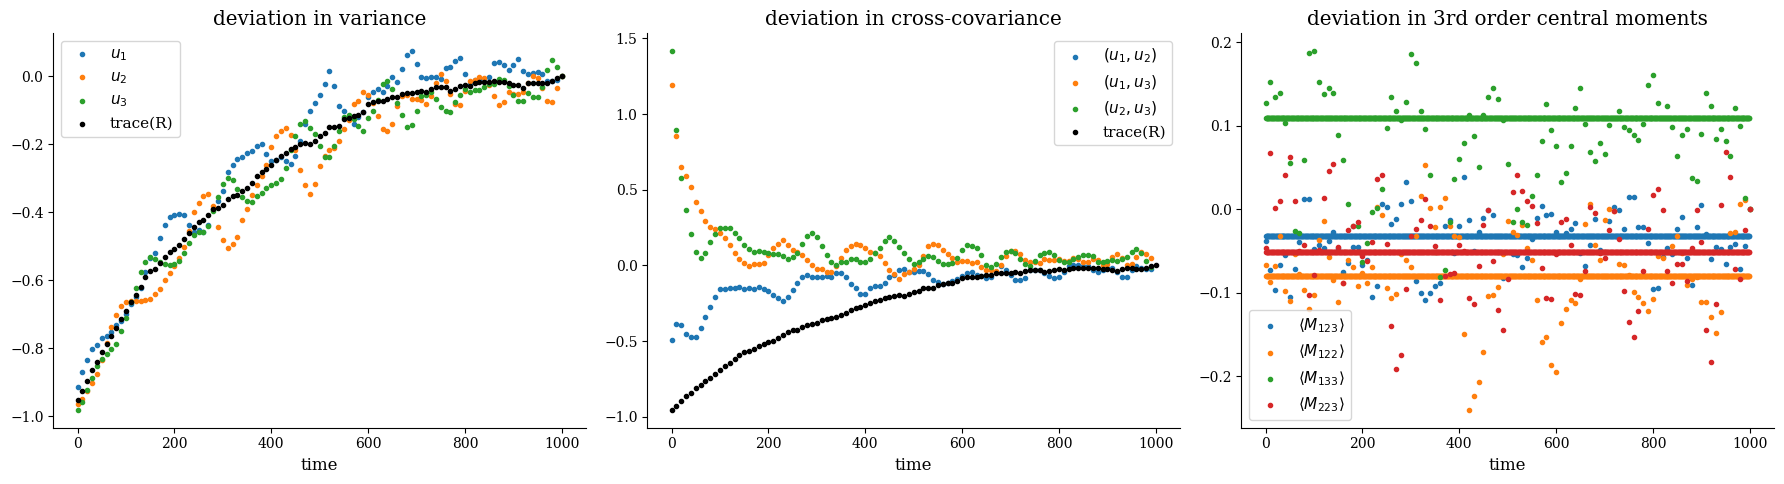

In [1]:
from MC_triad import *
import os
from pathlib import Path
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..",'..')))
from utils.plotting import plot_stats, plot_third_order_moments, plot_deviation_subplots
'''First, check the results of equation
1. why we need to use the deviation in variance and cross-covariance to plot the deviation in 3rd order central moments?
2. why we need to use the deviation in 3rd order central moments to plot the deviation in energy?
3. why we need to use the deviation in energy to plot the deviation in 3rd order central moments?
'''
dimension = 3
folder_name = 'equipart'
# Use the current working directory instead of __file__
params = params_init(folder_name)
model_path = Path(os.path.join(os.getcwd(), 'Results', folder_name))
data = np.load(os.path.join(model_path, 'simulation_results.npz')) 
mean_MC_all = data['mean_MC']
cov_MC_all = data['cov_MC']
moment3_MC_all = data['moment3_MC']
moment3_MC_norm_all = data['moment3_MC_norm']
Energy_MC_all = data['Energy_MC']
Energy_dyn = data['Energy_dyn']
plot_stats(np.arange(params['Nt']+1), mean_MC_all, cov_MC_all, moment3_MC_all, Energy_MC_all, Energy_dyn, os.path.join(model_path, 'stats.pdf'))
plot_third_order_moments(np.arange(params['Nt']+1), moment3_MC_all,os.path.join(model_path, 'third_order_moments.pdf'))
plot_deviation_subplots(np.arange(params['Nt']+1), cov_MC_all, moment3_MC_norm_all,os.path.join(model_path, 'deviation_subplots.pdf'))




In [ ]:
'''loading the model results
First part: for FEX model
'''
from utils.ODEParser import *
from utils.FEXParser import MultiDimFEXLoader
device = 'cuda' if torch.cuda.is_available() else 'cpu'

FEX_model = MultiDimFEXLoader(model_path, dimension, device)

'''Second part: for stochastic model'''
FN = FN_Net(dimension,dimension,50).to(device)
FN.load_state_dict(torch.load(os.path.join(model_path, 'FN_Net.pth'), map_location=device))

data_FEX = torch.load(os.path.join(model_path, 'data_inf.pt'), map_location=device)
xTrain_mean_FEX = data_FEX['SECOND_STAGE_TRAINING_DATA_MEAN']
xTrain_std_FEX = data_FEX['SECOND_STAGE_TRAINING_DATA_STD']
yTrain_mean_FEX = data_FEX['ODE_REVERSE_SOLUTION_MEAN']
yTrain_std_FEX = data_FEX['ODE_REVERSE_SOLUTION_STD']
diff_scale_FEX = data_FEX['diff_scale']


print(xTrain_mean_FEX)
print(xTrain_std_FEX)
print(yTrain_mean_FEX)
print(yTrain_std_FEX)
print(diff_scale_FEX)

    
def TWO_STAGE_Model(dt,INPUT_DATA,FEX_func,FN_func_params,device):
    if isinstance(INPUT_DATA, torch.Tensor):
        INPUT_DATA = INPUT_DATA.to(device)
    elif isinstance(INPUT_DATA, np.ndarray):
        INPUT_DATA = torch.tensor(INPUT_DATA, dtype=torch.float32).to(device)
    else:
        raise TypeError("INPUT_DATA must be a torch.Tensor or a numpy.ndarray")
    Npath = INPUT_DATA.shape[0]
    dim = INPUT_DATA.shape[1]
    xTrain_mean_FEX = FN_func_params['xTrain_mean']
    xTrain_std_FEX = FN_func_params['xTrain_std']
    yTrain_mean_FEX = FN_func_params['yTrain_mean']
    yTrain_std_FEX = FN_func_params['yTrain_std']
    stochastic_component = FN_func_params['FN_func']( (((torch.randn(Npath,dim).to(device,dtype= torch.float32)))-xTrain_mean_FEX)/xTrain_std_FEX  )* yTrain_std_FEX + yTrain_mean_FEX
    return dt*FEX_func(INPUT_DATA)+ stochastic_component
 
    
FN_func_params = {
    'xTrain_mean': xTrain_mean_FEX,
    'xTrain_std': xTrain_std_FEX,
    'yTrain_mean': yTrain_mean_FEX,
    'yTrain_std': yTrain_std_FEX,
    'diff_scale': diff_scale_FEX,
    'FN_func': FN,
}


tensor([[-1.5964e-04,  9.4974e-04,  1.0960e-03, -9.3458e-05,  1.7930e-03,
         -8.8344e-04]])
tensor([[2.0974, 2.0979, 2.0977, 1.0002, 0.9992, 0.9999]])
tensor([[-0.0041,  0.0120, -0.0056]])
tensor([[15.7329, 11.1633, 11.1663]])
100


NameError: name 'DEVICE' is not defined

In [ ]:

np.random.seed(0)
m0, var0 = MC_triad_initial_value()
params = params_init('equipart')
# dataset, mean_MC, cov_MC, moment3_MC, moment3_MC_norm,Energy_MC, Energy_dyn = MC_triad_direct(params, m0, var0)

print(m0)
TIME_AMOUNT = 5000
dt = 0.01
NPATH = 50000
x_pred_initial = torch.ones(NPATH, 3).to(device,dtype=torch.float32) * torch.tensor(m0).to(device,dtype=torch.float32)
# TWO_STAGE_Model(dt,x_pred_initial,FEX_model,FN_func_params,device)

for i in range(int(TIME_AMOUNT/dt)):
    if i % 10000 == 0:
        
        print(i)





# x_pred_new = torch.ones(Npath, x_dim).to(device,dtype=torch.float32) * torch.tensor(true_init).to(device,dtype=torch.float32)
# output = FEX_model(x_input)
# print(output.shape)



[-1.   0.5 -0.5]
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
